In [498]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import matplotlib as mpl

from scipy.stats import rayleigh
from scipy.stats import gaussian_kde

from matplotlib.legend_handler import HandlerBase
from matplotlib.lines import Line2D


In [499]:



class GradientLine:
    def __init__(self, cmap):
        self.cmap = cmap


class HandlerGradientLine(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height,
        fontsize, trans
    ):
        n = 30
        x = np.linspace(xdescent, xdescent + width, n + 1)
        y = ydescent + height / 2

        artists = []

        for i in range(n):
            line = Line2D(
                [x[i], x[i + 1]],
                [y, y],
                color=orig_handle.cmap(i / (n - 1)),
                linewidth=2.5,
                transform=trans
            )
            artists.append(line)

        return artists

In [500]:
def compute_cumulative_outcome_fractions(df, masses, N):
    """
    df      : DataFrame with columns ['mass', 'time', 'particle_id', 'result']
              where result is 'Ejected' or 'Captured', and each row represents
              the time at which that particle's outcome occurred
    masses  : list/array of unique mass values, in the same order as N
    N       : list/array of total particle counts, one per mass in `masses`

    Returns
    -------
    ejection_df, capture_df : DataFrames indexed by mass, columns = sorted
                               unique time values, entries = CUMULATIVE
                               fraction of N with that result by that time
                               (i.e. fraction ejected/captured at or before
                               each time, monotonically non-decreasing
                               across each row)
    """
    if len(masses) != len(N):
        raise ValueError("masses and N must be the same length")

    mass_to_N = dict(zip(masses, N))

    times = np.sort(df["time"].unique())

    ejection_df = pd.DataFrame(index=masses, columns=times, dtype=float)
    capture_df = pd.DataFrame(index=masses, columns=times, dtype=float)

    for mass in masses:
        mass_df = df[df["mass"] == mass]
        denom = mass_to_N[mass]

        counts = (
            mass_df.groupby(["time", "result"])
            .size()
            .unstack(fill_value=0)
        )

        # reindex to the full sorted time axis, filling any missing times
        # with 0 new outcomes at that time, then cumsum across time
        ejected_counts = counts.get("Ejected", pd.Series(0, index=counts.index))
        captured_counts = counts.get("Captured", pd.Series(0, index=counts.index))

        ejected_counts = ejected_counts.reindex(times, fill_value=0)
        captured_counts = captured_counts.reindex(times, fill_value=0)

        ejection_df.loc[mass] = (ejected_counts.cumsum() / denom).values
        capture_df.loc[mass] = (captured_counts.cumsum() / denom).values

    return ejection_df, capture_df

In [501]:
def get_ejected_initial_conditions_unordered(initial_df, final_df, mass):
    ejected_ids = final_df.loc[
        (final_df["mass"] == mass) &
        (final_df["result"] == "Ejected"),
        "particle_id"
    ].unique()

    return initial_df[
        initial_df["particle_id"].isin(ejected_ids)
    ].copy()

In [502]:
def power_law(m, A, alpha):
    return A * m**alpha

In [503]:
m_planet=np.logspace(-5,-3.5,5, endpoint=False)

In [504]:
m_planet

array([1.00000000e-05, 1.99526231e-05, 3.98107171e-05, 7.94328235e-05,
       1.58489319e-04])

In [505]:
m_planet=np.delete(m_planet, 1)

In [506]:
m_planet


array([1.00000000e-05, 3.98107171e-05, 7.94328235e-05, 1.58489319e-04])

In [507]:
A_inner = 3.729132931366645
alpha_inner = 0.14939347354180882

A_outer = 34.508406515008886
alpha_outer = 0.32060397131882085
r_max=1+1.05*power_law(m_planet, A_outer, alpha_outer)/5
r_min=1-1.05*power_law(m_planet, A_inner, alpha_inner)/5
scale_arr=(r_max-r_min)/(2)

In [508]:
scale_arr

array([0.16050263, 0.22694448, 0.27120757, 0.32513943])

In [509]:
df_30=pd.read_csv('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/2187505_ejection_results.txt', header=None)
df_10=pd.read_csv('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/2187497_ejection_results.txt', header=None)
df_50=pd.read_csv('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/2187513_ejection_results.txt', header=None)
df_1=pd.read_csv('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/2188349_ejection_results.txt', header=None)
df_1_lm=pd.read_csv('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/2186705_ejection_results.txt', header=None)

In [510]:
#df_1=pd.concat([df_1,df_1_lm])

In [511]:
pd.concat?

Signature:
pd.concat(
    objs: 'Iterable[Series | DataFrame] | Mapping[HashableT, Series | DataFrame]',
    *,
    axis: 'Axis' = 0,
    join: 'str' = 'outer',
    ignore_index: 'bool' = False,
    keys: 'Iterable[Hashable] | None' = None,
    levels=None,
    names: 'list[HashableT] | None' = None,
    verify_integrity: 'bool' = False,
    sort: 'bool' = False,
    copy: 'bool | None' = None,
) -> 'DataFrame | Series'
Docstring:
Concatenate pandas objects along a particular axis.

Allows optional set logic along the other axes.

Can also add a layer of hierarchical indexing on the concatenation axis,
which may be useful if the labels are the same (or overlapping) on
the passed axis number.

Parameters
----------
objs : a sequence or mapping of Series or DataFrame objects
    If a mapping is passed, the sorted keys will be used as the `keys`
    argument, unless it is passed, in which case the values will be
    selected (see below). Any None objects will be dropped silently unless
  

In [512]:
df_10

,0,1,2,3
0,0.010000,0.000000e+00,Captured,403
1,0.010000,0.000000e+00,Captured,196
2,0.010000,0.000000e+00,Captured,775
3,0.010000,0.000000e+00,Captured,296
4,0.010000,0.000000e+00,Captured,137
...,...,...,...,...
1713,0.000316,2.162656e+07,Ejected,335
1714,0.000316,2.213244e+07,Ejected,493
1715,0.000316,2.225892e+07,Ejected,462
1716,0.000316,2.254348e+07,Ejected,674


In [513]:
dfs=[df_1_lm,df_1,df_10, df_30, df_50]
for df in dfs:
    df.columns = ['mass', 'time', 'result', 'particle_id']


In [514]:
df_1_lm

,mass,time,result,particle_id
0,0.000040,0.000000e+00,Captured,209
1,0.000079,0.000000e+00,Captured,262
2,0.000079,6.999722e+03,Captured,10
3,0.000079,7.999682e+03,Captured,157
4,0.000079,5.699774e+04,Captured,791
...,...,...,...,...
1389,0.000079,2.360906e+07,Ejected,344
1390,0.000079,2.362206e+07,Ejected,505
1391,0.000040,1.713466e+07,Ejected,516
1392,0.000040,1.715266e+07,Ejected,303


In [515]:
ejection_df_30, capture_df_30 = compute_cumulative_outcome_fractions(df_30, df_30.mass.unique(), N=[800,800,800,800,800,800])
ejection_df_10, capture_df_10 = compute_cumulative_outcome_fractions(df_10, df_10.mass.unique(), N=[800,800,800,800,800,800])
ejection_df_50, capture_df_50 = compute_cumulative_outcome_fractions(df_50, df_50.mass.unique(), N=[800,800,800,800,800,800])
ejection_df_1, capture_df_1 = compute_cumulative_outcome_fractions(df_1, df_1.mass.unique(), N=[800,800,800,800,800,800])
ejection_df_1_lm,capture_df_1_lm=compute_cumulative_outcome_fractions(df_1_lm,df_1_lm.mass.unique(), N=[800,800,800,800])

In [528]:
ejection_df_1_lm

,0.000000e+00,6.999722e+03,7.999682e+03,2.399810e+04,5.099596e+04,5.699774e+04,1.419944e+05,1.669868e+05,1.769860e+05,2.369988e+05,...,1.742331e+07,1.745631e+07,1.775829e+07,1.802928e+07,1.828527e+07,1.831827e+07,1.835627e+07,1.893025e+07,2.360906e+07,2.362206e+07
0.000079,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000284,0.000284,0.000284,0.000284,...,0.147230,0.147514,0.147798,0.148081,0.148365,0.148649,0.148932,0.149216,0.149500,0.149783
0.000158,0.0,0.0,0.0,0.000339,0.000678,0.000678,0.000678,0.001017,0.001356,0.001356,...,0.174251,0.174251,0.174251,0.174251,0.174251,0.174251,0.174251,0.174251,0.174251,0.174251


In [531]:
ejection_df_1_lm.index

Index([7.943282347242821e-05, 0.0001584893192461], dtype='float64')

In [533]:
np.logspace(-4.1,-3.8,2)

array([7.94328235e-05, 1.58489319e-04])

In [529]:
(2.02731513e+01*0.000079**(-3/2) + 6.97903308e+04)*30

868261200.0989124

In [517]:
num_cols = ejection_df_1_lm.select_dtypes(include="number").columns

ejection_df_1_lm[num_cols] = ejection_df_1_lm[num_cols].mul(
    scale_arr,
    axis=0
)

In [518]:
#ejection_df_1=pd.concat([ejection_df_1,ejection_df_1_lm])

In [519]:
ejection_df_1_lm.drop(index=[10**(-5), 10**(-4.4)], inplace=True)

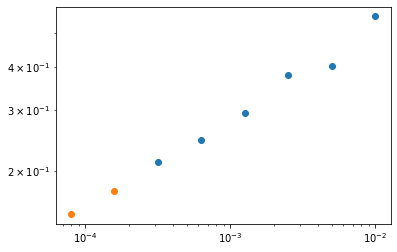

In [520]:
plt.scatter(ejection_df_1.index,ejection_df_1[ejection_df_1.columns[-1]])
plt.scatter(ejection_df_1_lm.index,ejection_df_1_lm[ejection_df_1_lm.columns[-1]])

plt.yscale('log')
plt.xscale('log')

In [521]:
ejection_df_1

,0.000000e+00,8.994340e+03,1.393052e+04,1.691563e+04,1.791067e+04,1.890571e+04,1.990074e+04,2.089578e+04,2.189082e+04,2.199306e+04,...,1.456770e+06,1.464768e+06,1.610745e+06,1.619744e+06,1.652739e+06,1.781718e+06,1.799715e+06,1.913697e+06,1.965689e+06,2.019681e+06
0.002512,0.0,0.0,0.00000,0.000,0.00000,0.00000,0.00,0.00000,0.00000,0.00000,...,0.37875,0.37875,0.37875,0.37875,0.37875,0.37875,0.37875,0.37875,0.37875,0.37875
0.000631,0.0,0.0,0.00000,0.000,0.00000,0.00000,0.00,0.00000,0.00000,0.00125,...,0.24500,0.24500,0.24500,0.24500,0.24500,0.24500,0.24500,0.24500,0.24500,0.24500
0.010000,0.0,0.0,0.00125,0.005,0.00625,0.01125,0.02,0.02875,0.04125,0.04125,...,0.55875,0.55875,0.55875,0.55875,0.55875,0.55875,0.55875,0.55875,0.55875,0.55875
0.005012,0.0,0.0,0.00000,0.000,0.00000,0.00000,0.00,0.00000,0.00000,0.00000,...,0.40250,0.40250,0.40250,0.40250,0.40250,0.40250,0.40250,0.40250,0.40250,0.40250
0.001259,0.0,0.0,0.00000,0.000,0.00000,0.00000,0.00,0.00000,0.00000,0.00000,...,0.29375,0.29375,0.29375,0.29375,0.29375,0.29375,0.29375,0.29375,0.29375,0.29375
0.000316,0.0,0.0,0.00000,0.000,0.00000,0.00000,0.00,0.00000,0.00000,0.00000,...,0.20000,0.20125,0.20250,0.20375,0.20500,0.20625,0.20750,0.20875,0.21000,0.21125


In [522]:
ejection_df_30.columns[-2]/30**(3/2)

1124822.1640580012

In [523]:
ejection_dfs=[ejection_df_1, ejection_df_10, ejection_df_30, ejection_df_50]
for ejection_df in ejection_dfs:
    ejection_df.sort_index(ascending=False, inplace=True)

In [524]:
r_min=0
r_max=125

In [525]:
a_arr = np.array([1,10, 30, 50])
for ejection_df, a in zip(ejection_dfs, a_arr):
    disc_fraction=3*a/(r_max-r_min)*ejection_df[ejection_df.columns[-1]]
    ejection_df['disc_fraction'] = disc_fraction

In [526]:
ejection_df_30[ejection_df_30.columns[-1]]

0.010000    0.3915
0.005012    0.3231
0.002512    0.2367
0.001259    0.2214
0.000631    0.1962
0.000316    0.1638
Name: disc_fraction, dtype: float64

TypeError: object of type 'Axes' has no len()

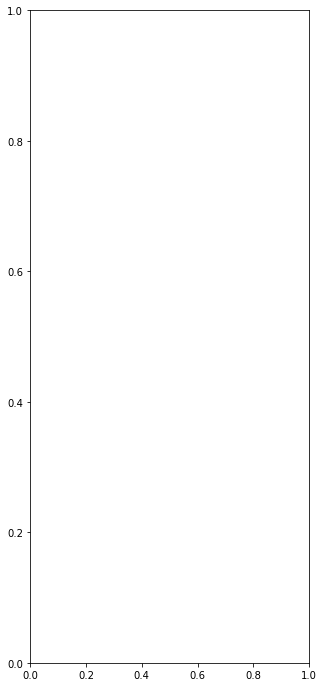

In [527]:
#colors = ['black','blue', 'orange', 'green']
colors = plt.cm.Blues(
    np.linspace(0.5, 1, len(a_arr))
)
fig, axes = plt.subplots(
    1, 1,
    figsize=(5, 12),
    sharey=False
)

#axes = axes.ravel()
for i in range(len(axes)):
    for ejection_df, color, a in zip(ejection_dfs, colors, a_arr):
        ax.plot(ejection_df.index, ejection_df[ejection_df.columns[-2+i]], label=f'{a} AU', color=color, marker='o')
    ax.set_yscale('log')
    ax.set_xscale('log')
    
axes[0].set_ylabel('Ejected Local Mass Fraction')
axes[1].set_ylabel('Ejected Disc Mass Fraction')
fig.supxlabel('Mass Ratio')
fig.suptitle('Ejected Mass Fraction vs Mass Ratio')
fig.tight_layout()
axes[0].legend(loc='lower right')
#plt.savefig('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Visualizations/two_panel_e_frac.png', bbox_inches='tight', facecolor='white')

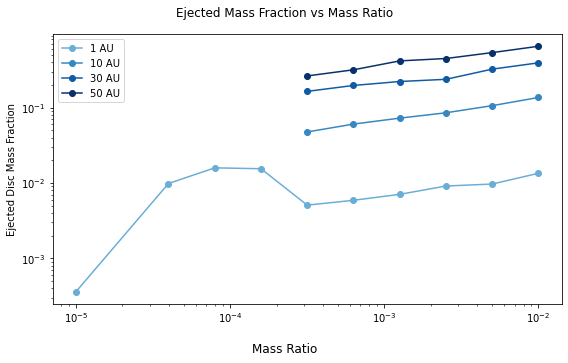

In [ ]:
#colors = ['black','blue', 'orange', 'green']
colors = plt.cm.Blues(
    np.linspace(0.5, 1, len(a_arr))
)
fig, ax = plt.subplots(
    1, 1,
    figsize=(8, 5),
    sharey=False
)

#axes = axes.ravel()
#for i in range(2):
    
        
ax.set_yscale('log')
ax.set_xscale('log')
for ejection_df, color, a in zip(ejection_dfs, colors, a_arr):
    ax.plot(ejection_df.index, ejection_df[ejection_df.columns[-1]], label=f'{a} AU', color=color, marker='o')
plt.legend(loc='lower left')
# for ejection_df, color, a in zip(ejection_dfs, colors, a_arr):
#     ax.plot(ejection_df.index, ejection_df[ejection_df.columns[-2]], label=f'{a} AU', color=color, marker='o')

    
ax.set_ylabel('Ejected Local Mass Fraction')
ax.set_ylabel('Ejected Disc Mass Fraction')
fig.supxlabel('Mass Ratio')
fig.suptitle('Ejected Mass Fraction vs Mass Ratio')
fig.tight_layout()
ax.legend()
#plt.savefig('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Visualizations/one_panel_disc_mass.png')

In [ ]:
job_ids = [2188349,2187497, 2187505, 2187513]   

In [ ]:
df_is_list = []
df_fs=[]
for job_id in job_ids:
    df_is=[]
    


    for i in range(6):
        f=f'/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Particle_Tracking/{job_id}-{i}_initial_particles.txt'
        df=pd.read_csv(f, header=None)
        df.columns=['a','e','particle_id']

        df_is.append(df)
    f=f'/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/{job_id}_ejection_results.txt'
    df=pd.read_csv(f, header=None)
    df.columns=['mass','time','result','particle_id']

    df_fs.append(df)
    df_is_list.append(df_is)

In [ ]:
df_f=df_10

In [ ]:
masses=np.logspace(-2,-3.5, 6)

In [ ]:
df_is

[              a         e  particle_id
 0    117.470590  0.147682            0
 1    108.461336  0.097948            3
 2     47.269692  0.150190            2
 3     80.677953  0.097245            1
 4     46.044466  0.141261            7
 ..          ...       ...          ...
 795   30.704284  0.142723          782
 796   51.894116  0.192425          786
 797   68.334485  0.233486          790
 798   27.306512  0.061824          794
 799   27.973399  0.100049          798
 
 [800 rows x 3 columns],
               a         e  particle_id
 0    110.003866  0.118176            3
 1    112.156835  0.166028            1
 2    109.946636  0.108355            2
 3     78.867506  0.078542            0
 4     50.114213  0.066737            7
 ..          ...       ...          ...
 795   48.612776  0.162352          794
 796   78.864511  0.175675          795
 797  107.372856  0.321147          798
 798   38.234341  0.274427          796
 799   57.141815  0.081558          799
 
 [800 rows 

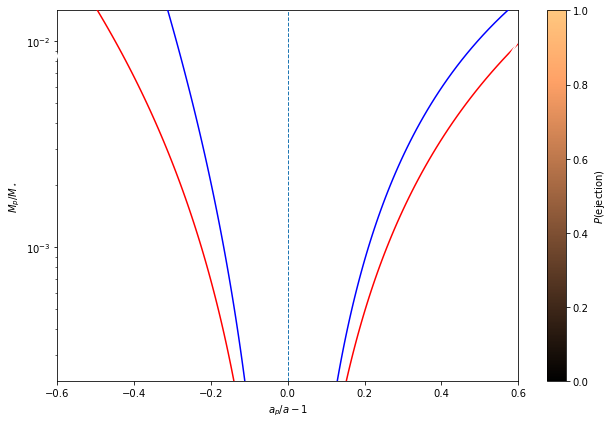

In [ ]:



# ============================================================
# REDEFINED HERE
# ============================================================

a_planet = 10.0

# Your variable `masses` contains log10(mass).
# df_f["mass"] contains the actual mass.
mass_values = masses

# Keep the same number of bins that you previously had in a.


# Your chosen coordinate:
#
#     x = a_planet / a - 1
#
# Determine the x-range corresponding to the old a-range.

n_bins = 26          # MUST be odd
x_max = 0.6          # choose desired extent

x_edges = np.linspace(
    -x_max,
    x_max,
    n_bins + 1
)

x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])


# ============================================================
# CALCULATE EJECTION PROBABILITY IN EACH x BIN
# ============================================================

P = []

for mass, df_i in zip(mass_values, df_is):

    # Results corresponding to this planet mass
    final_df = df_f[
        np.isclose(df_f["mass"], mass)
    ]

    # Particle IDs that eventually ejected
    ejected_ids = final_df.loc[
        final_df["result"] == "Ejected",
        "particle_id"
    ].unique()

    df = df_i.copy()

    # Identify ejected particles
    df["ejected"] = df["particle_id"].isin(ejected_ids)

    # --------------------------------------------------------
    # IMPORTANT CHANGE:
    # Transform EACH PARTICLE to x before histogramming.
    # --------------------------------------------------------
    df["x"] = a_planet / df["a"] - 1


    # Number of all particles initially in each x bin
    N_all, _ = np.histogram(
        df["x"],
        bins=x_edges
    )

    # Number of ejected particles initially in each x bin
    N_ej, _ = np.histogram(
        df.loc[df["ejected"], "x"],
        bins=x_edges
    )
    

    # Probability of ejection
    p = np.divide(
        N_ej,
        N_all,
        out=np.full_like(
            N_ej,
            np.nan,
            dtype=float
        ),
        where=N_all > 0
    )

    P.append(p)


P = np.asarray(P)


# ============================================================
# SORT MASSES
# ============================================================

# pcolormesh is easiest to reason about with increasing y.
mass_order = np.argsort(mass_values)

mass_values = mass_values[mass_order]
P = P[mass_order, :]


# ============================================================
# DEFINE MASS-BIN EDGES
# ============================================================
#
# The masses are logarithmically spaced, so their visual
# boundaries should be halfway between them in log10 space.
# ============================================================

log_masses = np.log10(mass_values)

log_mass_edges = np.empty(len(log_masses) + 1)

# Interior edges
log_mass_edges[1:-1] = 0.5 * (
    log_masses[:-1] + log_masses[1:]
)

# Extrapolate first and last edges
log_mass_edges[0] = (
    log_masses[0]
    - 0.5 * (log_masses[1] - log_masses[0])
)

log_mass_edges[-1] = (
    log_masses[-1]
    + 0.5 * (log_masses[-1] - log_masses[-2])
)

mass_edges = 10**log_mass_edges


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))


mesh = ax.pcolormesh(
    x_edges,
    mass_edges,
    P,
    shading="flat",
    vmin=0,
    vmax=1,
    cmap="copper"
)

ax.set_yscale("log")

ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_xlabel(r"$a_p/a - 1$")
ax.set_ylabel(r"$M_p/M_\star$")

cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label(r"$P(\mathrm{ejection})$")

plot_masses=np.logspace(-1, -4, 100)

HS_values=a_planet*(plot_masses/(3*(1+plot_masses)))**(1/3)
inv_HS_values_inner=a_planet/(a_planet-HS_values)-1
inv_HS_values_outer=a_planet/(a_planet+HS_values)-1

CZ_values_inner=1.2*(plot_masses**0.28*a_planet)
CZ_values_outer=1.7*(plot_masses**0.31*a_planet)

inv_CZ_values_inner=a_planet/(a_planet-CZ_values_inner)-1
inv_CZ_values_outer=a_planet/(a_planet+CZ_values_outer)-1

A_inner = 3.729132931366645
alpha_inner = 0.14939347354180882

A_outer = 34.508406515008886
alpha_outer = 0.32060397131882085
fit_outer=a_planet+2*power_law(plot_masses, A_outer, alpha_outer)
fit_inner=a_planet-2*power_law(plot_masses, A_inner, alpha_inner)

inv_fit_outer=a_planet/(fit_outer)-1
inv_fit_inner=a_planet/(fit_inner)-1

plt.plot(2*np.sqrt(3)*inv_HS_values_inner,plot_masses,  color='red', label='Hill Sphere', zorder=10)
plt.plot(2*np.sqrt(3)*inv_HS_values_outer,plot_masses,  color='red', label='Hill Sphere', zorder=10)
plt.plot(inv_CZ_values_inner,plot_masses,  color='blue', label='Chambers-Zhang', zorder=10)
plt.plot(inv_CZ_values_outer,plot_masses,  color='blue', label='Chambers-Zhang', zorder=10)
plt.plot(inv_fit_inner,plot_masses,  color='white', label='Power Law Fit', zorder=10)
plt.plot(inv_fit_outer,plot_masses,  color='white', label='Power Law Fit', zorder=10)

plt.tight_layout()
plt.xlim(-0.6,0.6)
plt.ylim(mass_edges.min(),mass_edges.max())
plt.show()

In [ ]:
a_planets=[1,10, 30, 50]

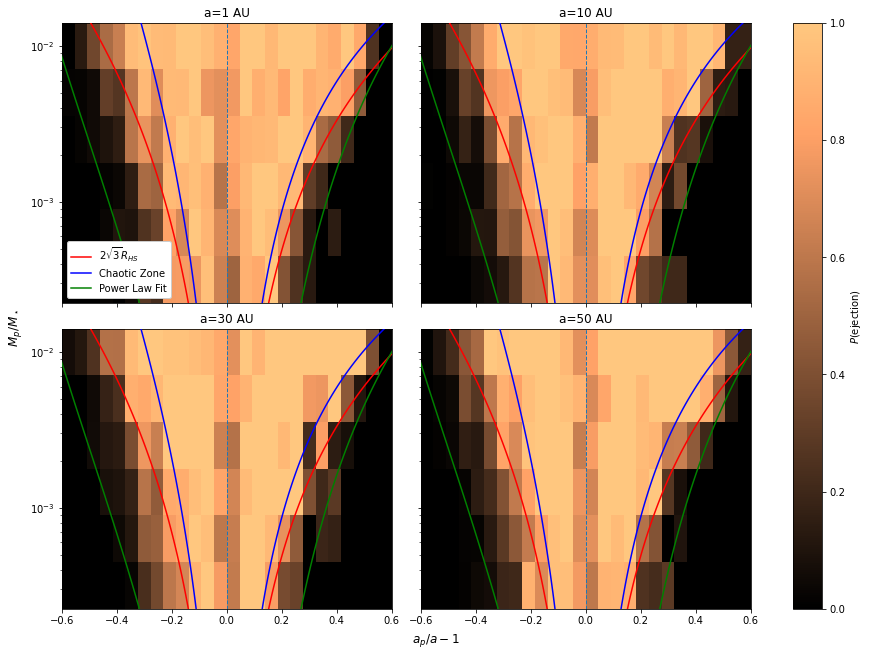

In [ ]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 9),
    sharex=True,
    sharey=True,
    layout='constrained'
)

axes = axes.ravel()

for i, (ax, df_is, a_planet, df_f) in enumerate(zip(axes, df_is_list, a_planets, df_fs)):
        


    # ============================================================
    # REDEFINED HERE
    # ============================================================

    #a_planet = 10.0

    # Your variable `masses` contains log10(mass).
    # df_f["mass"] contains the actual mass.
    mass_values = masses

    # Keep the same number of bins that you previously had in a.


    # Your chosen coordinate:
    #
    #     x = a_planet / a - 1
    #
    # Determine the x-range corresponding to the old a-range.

    n_bins = 26          # MUST be odd
    x_max = 0.6          # choose desired extent

    x_edges = np.linspace(
        -x_max,
        x_max,
        n_bins + 1
    )

    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])


    # ============================================================
    # CALCULATE EJECTION PROBABILITY IN EACH x BIN
    # ============================================================

    P = []

    for mass, df_i in zip(mass_values, df_is):

        # Results corresponding to this planet mass
        final_df = df_f[
            np.isclose(df_f["mass"], mass)
        ]

        # Particle IDs that eventually ejected
        ejected_ids = final_df.loc[
            final_df["result"] == "Ejected",
            "particle_id"
        ].unique()

        df = df_i.copy()

        # Identify ejected particles
        df["ejected"] = df["particle_id"].isin(ejected_ids)

        # --------------------------------------------------------
        # IMPORTANT CHANGE:
        # Transform EACH PARTICLE to x before histogramming.
        # --------------------------------------------------------
        df["x"] = a_planet / df["a"] - 1


        # Number of all particles initially in each x bin
        N_all, _ = np.histogram(
            df["x"],
            bins=x_edges
        )

        # Number of ejected particles initially in each x bin
        N_ej, _ = np.histogram(
            df.loc[df["ejected"], "x"],
            bins=x_edges
        )
        

        # Probability of ejection
        p = np.divide(
            N_ej,
            N_all,
            out=np.full_like(
                N_ej,
                np.nan,
                dtype=float
            ),
            where=N_all > 0
        )

        P.append(p)


    P = np.asarray(P)


    # ============================================================
    # SORT MASSES
    # ============================================================

    # pcolormesh is easiest to reason about with increasing y.
    mass_order = np.argsort(mass_values)

    mass_values = mass_values[mass_order]
    P = P[mass_order, :]


    # ============================================================
    # DEFINE MASS-BIN EDGES
    # ============================================================
    #
    # The masses are logarithmically spaced, so their visual
    # boundaries should be halfway between them in log10 space.
    # ============================================================

    log_masses = np.log10(mass_values)

    log_mass_edges = np.empty(len(log_masses) + 1)

    # Interior edges
    log_mass_edges[1:-1] = 0.5 * (
        log_masses[:-1] + log_masses[1:]
    )

    # Extrapolate first and last edges
    log_mass_edges[0] = (
        log_masses[0]
        - 0.5 * (log_masses[1] - log_masses[0])
    )

    log_mass_edges[-1] = (
        log_masses[-1]
        + 0.5 * (log_masses[-1] - log_masses[-2])
    )

    mass_edges = 10**log_mass_edges


    # ============================================================
    # PLOT
    # ============================================================




    mesh = ax.pcolormesh(
        x_edges,
        mass_edges,
        P,
        shading="flat",
        vmin=0,
        vmax=1,
        cmap="copper"
    )

    ax.set_yscale("log")

    ax.axvline(
        0,
        linestyle="--",
        linewidth=1
    )



    

    plot_masses=np.logspace(-1, -4, 100)

    HS_values=a_planet*(plot_masses/(3*(1+plot_masses)))**(1/3)
    inv_HS_values_inner=a_planet/(a_planet-HS_values)-1
    inv_HS_values_outer=a_planet/(a_planet+HS_values)-1

    CZ_values_inner=1.2*(plot_masses**0.28*a_planet)
    CZ_values_outer=1.7*(plot_masses**0.31*a_planet)

    inv_CZ_values_inner=a_planet/(a_planet-CZ_values_inner)-1
    inv_CZ_values_outer=a_planet/(a_planet+CZ_values_outer)-1

    A_inner = 3.729132931366645
    alpha_inner = 0.14939347354180882

    A_outer = 34.508406515008886
    alpha_outer = 0.32060397131882085
    fit_outer=a_planet+a_planet*power_law(plot_masses, A_outer, alpha_outer)/5
    fit_inner=a_planet-a_planet*power_law(plot_masses, A_inner, alpha_inner)/5

    inv_fit_outer=a_planet/(fit_outer)-1
    inv_fit_inner=a_planet/(fit_inner)-1

    ax.plot(2*np.sqrt(3)*inv_HS_values_inner,plot_masses,  color='red', label=r'$2\sqrt{3}R_{HS}$', zorder=10)
    ax.plot(2*np.sqrt(3)*inv_HS_values_outer,plot_masses,  color='red', zorder=10)
    ax.plot(inv_CZ_values_inner,plot_masses,  color='blue', label='Chaotic Zone', zorder=10)
    ax.plot(inv_CZ_values_outer,plot_masses,  color='blue', zorder=10)
    ax.plot(inv_fit_inner,plot_masses,  color='green', zorder=10)
    ax.plot(inv_fit_outer,plot_masses,  color='green', label='Power Law Fit', zorder=10)

    ax.set_xlim(-0.6,0.6)
    ax.set_ylim(mass_edges.min(),mass_edges.max())
    ax.set_title(f'a={a_planet} AU')
leg=axes[0].legend(loc='lower left', framealpha=1)
leg.set_zorder(15)
cbar = fig.colorbar(mesh, ax=axes)
cbar.set_label(r"$P(\mathrm{ejection})$")
fig.supylabel(r"$M_p/M_\star$")
fig.supxlabel(r"$a_p/a - 1$")

#plt.savefig('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Visualizations/four_panel_P_heatmap.png',bbox_inches='tight',facecolor='white')

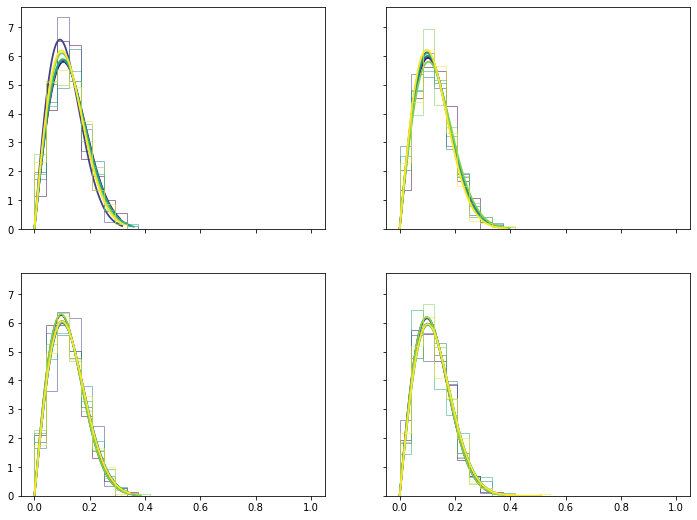

In [ ]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 9),
    sharex=True,
    sharey=True
)

axes = axes.ravel()

for i, (ax, df_is, a_planet, df_f) in enumerate(zip(axes, df_is_list, a_planets, df_fs)):
    P = []
    
    for mass, df_i in zip(mass_values, df_is):

        # Results corresponding to this planet mass
        final_df = df_f[
            np.isclose(df_f["mass"], mass)
        ]

        # Particle IDs that eventually ejected
        ejected_ids = final_df.loc[
            final_df["result"] == "Ejected",
            "particle_id"
        ].unique()

        df = df_i.copy()

        # Identify ejected particles
        df["ejected"] = df["particle_id"].isin(ejected_ids)
        e = df.loc[df["ejected"], "e"].dropna().to_numpy()

        color = cmap(norm(mass))

        # normalized histogram
        ax.hist(
            e,
            bins=bins,
            density=True,
            histtype="step",
            color=color,
            alpha=0.5
        )

        # Rayleigh fit to ejected population
        sigma_fit = rayleigh.fit(e, floc=0)[1]

        x = np.linspace(0, e.max(), 300)

        ax.plot(
            x,
            rayleigh.pdf(x, loc=0, scale=sigma_fit),
            color=color,
            linewidth=1.8
        )


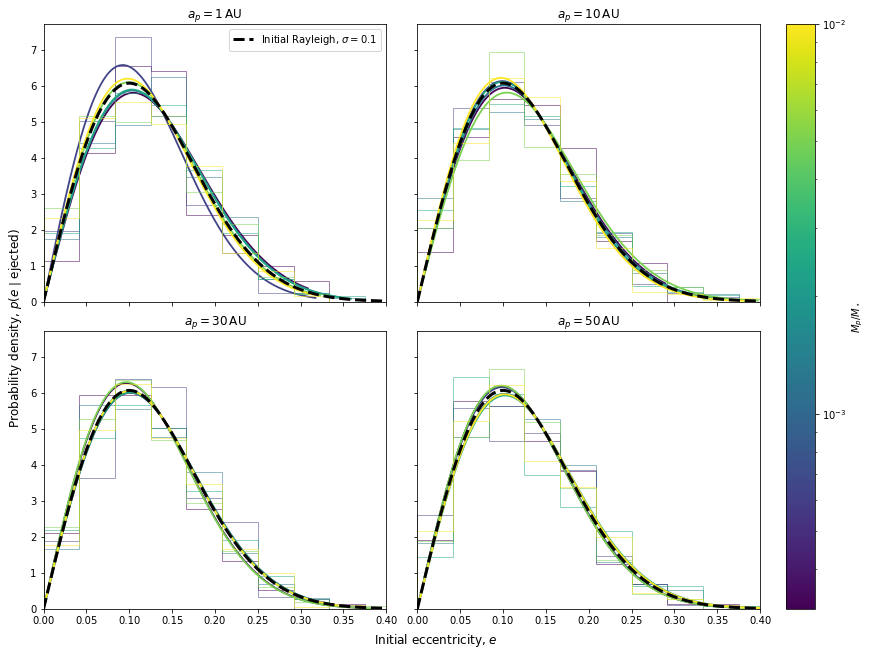

In [ ]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 9),
    sharex=True,
    sharey=True,
    layout='constrained'
)

axes = axes.ravel()

norm = mpl.colors.LogNorm(
    vmin=np.min(mass_values),
    vmax=np.max(mass_values)
)
cmap = plt.cm.viridis

bins = np.linspace(0, 1, 25)

for i, (ax, df_is, a_planet, df_f) in enumerate(
    zip(axes, df_is_list, a_planets, df_fs)
):
    

    for mass, df_i in zip(mass_values, df_is):

        final_df = df_f[
            np.isclose(df_f["mass"], mass)
        ]

        ejected_ids = final_df.loc[
            final_df["result"] == "Ejected",
            "particle_id"
        ].unique()

        df = df_i.copy()

        df["ejected"] = df["particle_id"].isin(ejected_ids)

        e = df.loc[df["ejected"], "e"].dropna().to_numpy()

        color = cmap(norm(mass))

        # normalized histogram
        ax.hist(
            e,
            bins=bins,
            density=True,
            histtype="step",
            color=color,
            alpha=0.5
        )

        # Rayleigh fit to ejected population
        sigma_fit = rayleigh.fit(e, floc=0)[1]

        x = np.linspace(0, e.max(), 300)

        ax.plot(
            x,
            rayleigh.pdf(x, loc=0, scale=sigma_fit),
            color=color,
            linewidth=1.8
        )
        ax.set_xlim(0, 0.4)
    x = np.linspace(0, 0.5, 300)
    
    ax.plot(
        x,
        rayleigh.pdf(x, scale=0.1),
        "k--",
        linewidth=3,
        label=r"Initial Rayleigh, $\sigma=0.1$"
    )
    ax.set_title(fr"$a_p = {a_planet}\,\mathrm{{AU}}$")


fig.supxlabel(r"Initial eccentricity, $e$")
fig.supylabel(r"Probability density, $p(e\mid \mathrm{ejected})$")

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(
    sm,
    ax=axes.tolist(),
    pad=0.02
)
cbar.set_label(r"$M_p/M_\star$")
axes[0].legend()

plt.savefig('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Visualizations/four_panel_eccentricity_density.png', bbox_inches='tight',facecolor='white')

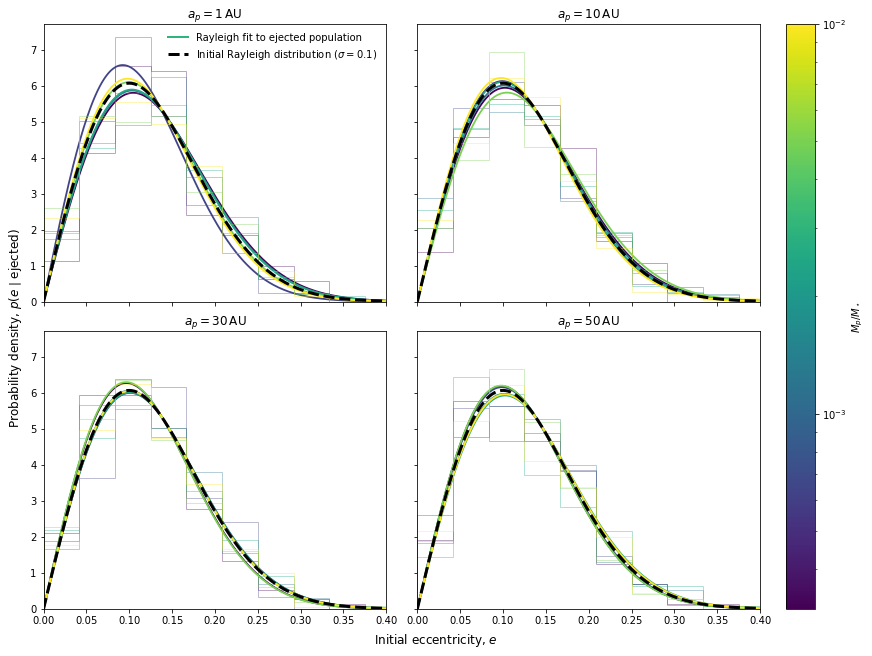

In [ ]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 9),
    sharex=True,
    sharey=True,
    layout="constrained"
)

axes = axes.ravel()

norm = mpl.colors.LogNorm(
    vmin=np.min(mass_values),
    vmax=np.max(mass_values)
)

cmap = plt.cm.viridis
bins = np.linspace(0, 1, 25)

for i, (ax, df_is, a_planet, df_f) in enumerate(
    zip(axes, df_is_list, a_planets, df_fs)
):

    for mass, df_i in zip(mass_values, df_is):

        final_df = df_f[
            np.isclose(df_f["mass"], mass)
        ]

        ejected_ids = final_df.loc[
            final_df["result"] == "Ejected",
            "particle_id"
        ].unique()

        df = df_i.copy()

        df["ejected"] = df["particle_id"].isin(ejected_ids)

        e = df.loc[
            df["ejected"],
            "e"
        ].dropna().to_numpy()

        color = cmap(norm(mass))

        # Probability-density histogram
        ax.hist(
            e,
            bins=bins,
            density=True,
            histtype="step",
            color=color,
            alpha=0.35,
            linewidth=1.0
        )

        # Rayleigh fit
        sigma_fit = rayleigh.fit(e, floc=0)[1]

        x = np.linspace(0, 0.4, 300)

        ax.plot(
            x,
            rayleigh.pdf(
                x,
                loc=0,
                scale=sigma_fit
            ),
            color=color,
            linewidth=1.8
        )

    # Initial distribution
    x = np.linspace(0, 0.4, 300)

    ax.plot(
        x,
        rayleigh.pdf(x, scale=0.1),
        color="black",
        linestyle="--",
        linewidth=3,
        zorder=10
    )

    ax.set_xlim(0, 0.4)

    ax.set_title(
        fr"$a_p = {a_planet}\,\mathrm{{AU}}$"
    )


fig.supxlabel(r"Initial eccentricity, $e$")
fig.supylabel(
    r"Probability density, $p(e\mid\mathrm{ejected})$"
)


# ----------------------------------
# Colorbar: indicates planet mass
# ----------------------------------

sm = mpl.cm.ScalarMappable(
    norm=norm,
    cmap=cmap
)

cbar = fig.colorbar(
    sm,
    ax=axes.tolist(),
    pad=0.02
)

cbar.set_label(r"$M_p/M_\star$")


# ----------------------------------
# Legend: indicates line meaning
# ----------------------------------

rayleigh_fit_handle = Line2D(
    [0], [0],
    color=cmap(0.65),     # representative color
    linewidth=2.0,
    label="Rayleigh fit to ejected population"
)

initial_handle = Line2D(
    [0], [0],
    color="black",
    linestyle="--",
    linewidth=3,
    label=r"Initial Rayleigh distribution ($\sigma=0.1$)"
)

axes[0].legend(
    handles=[
        rayleigh_fit_handle,
        initial_handle
    ],
    frameon=False,
    loc="upper right"
)

#plt.savefig('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Visualizations/four_panel_eccentricity_density.png', bbox_inches='tight',facecolor='white')

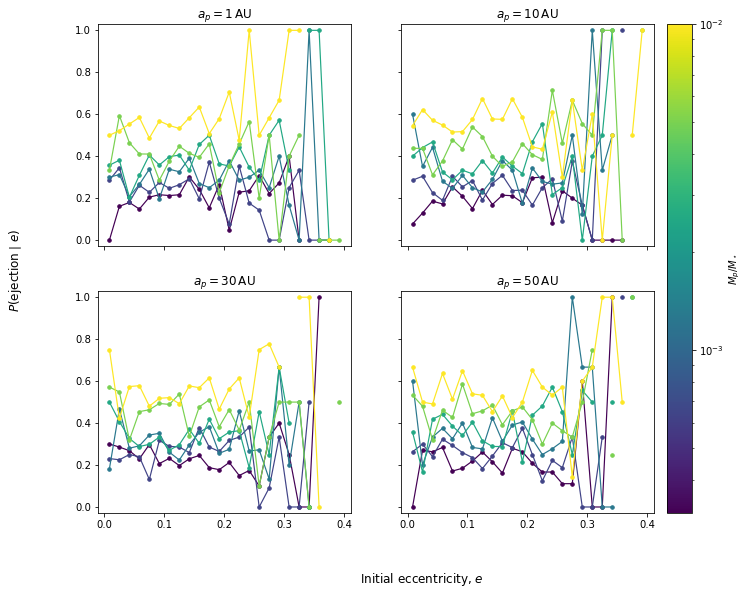

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 9),
    sharex=True,
    sharey=True
)

axes = axes.ravel()

norm = mpl.colors.LogNorm(
    vmin=np.min(mass_values),
    vmax=np.max(mass_values)
)

cmap = plt.cm.viridis

# Same eccentricity bins for all panels/masses
e_bins = np.linspace(0, 0.4, 25)

for i, (ax, df_is, a_planet, df_f) in enumerate(
    zip(axes, df_is_list, a_planets, df_fs)
):

    for mass, df_i in zip(mass_values, df_is):

        final_df = df_f[
            np.isclose(df_f["mass"], mass)
        ]

        ejected_ids = final_df.loc[
            final_df["result"] == "Ejected",
            "particle_id"
        ].unique()

        df = df_i.copy()

        df["ejected"] = df["particle_id"].isin(ejected_ids)

        # All initial particles in each eccentricity bin
        N_all, edges = np.histogram(
            df["e"],
            bins=e_bins
        )

        # Ejected particles in each eccentricity bin
        N_ejected, _ = np.histogram(
            df.loc[df["ejected"], "e"],
            bins=e_bins
        )

        # P(eject | e)
        p_eject = np.divide(
            N_ejected,
            N_all,
            out=np.full_like(
                N_ejected,
                np.nan,
                dtype=float
            ),
            where=N_all > 0
        )

        centers = 0.5 * (
            edges[:-1] + edges[1:]
        )

        ax.plot(
            centers,
            p_eject,
            marker="o",
            markersize=3.5,
            linewidth=1.2,
            color=cmap(norm(mass))
        )

    ax.set_title(
        fr"$a_p={a_planet}\,\mathrm{{AU}}$"
    )

    ax.set_ylim(-0.03, 1.03)


fig.supxlabel(r"Initial eccentricity, $e$")
fig.supylabel(
    r"$P(\mathrm{ejection}\mid e)$"
)

sm = mpl.cm.ScalarMappable(
    norm=norm,
    cmap=cmap
)

cbar = fig.colorbar(
    sm,
    ax=axes.tolist(),
    pad=0.02
)

cbar.set_label(r"$M_p/M_\star$")

plt.show()

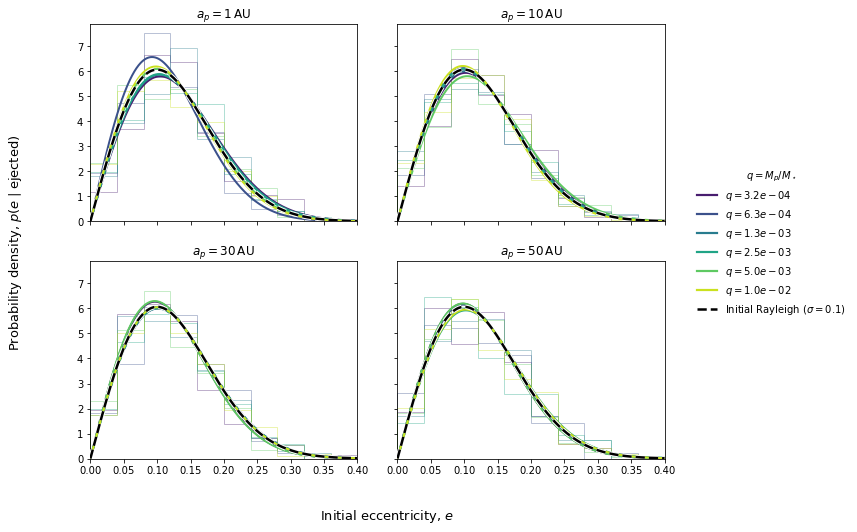

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from scipy.stats import rayleigh
from matplotlib.lines import Line2D


# --------------------------------------------------
# Plot settings
# --------------------------------------------------

sigma_initial = 0.1

bins = np.linspace(0, 0.4, 11)
x = np.linspace(0, 0.4, 500)

colors = plt.cm.viridis(
    np.linspace(0.08, 0.92, len(mass_values))
)


# --------------------------------------------------
# Figure
# --------------------------------------------------

fig, axes = plt.subplots(
    2, 2,
    figsize=(11, 8),
    sharex=True,
    sharey=True
)

axes = axes.ravel()


# --------------------------------------------------
# Panels
# --------------------------------------------------

for ax, df_is, a_planet, df_f in zip(
    axes,
    df_is_list,
    a_planets,
    df_fs
):

    for mass, df_i, color in zip(
        mass_values,
        df_is,
        colors
    ):

        # Final results for this planet mass
        final_df = df_f[
            np.isclose(df_f["mass"], mass)
        ]

        # IDs of ejected particles
        ejected_ids = final_df.loc[
            final_df["result"] == "Ejected",
            "particle_id"
        ].unique()

        # Initial conditions of particles that ejected
        df = df_i.copy()

        e = df.loc[
            df["particle_id"].isin(ejected_ids),
            "e"
        ].dropna().to_numpy()

        if len(e) < 2:
            continue

        # ------------------------------------------
        # Faint probability-density histogram
        # ------------------------------------------

        ax.hist(
            e,
            bins=bins,
            density=True,
            histtype="step",
            color=color,
            linewidth=1.0,
            alpha=0.35,
            zorder=1
        )

        # ------------------------------------------
        # Rayleigh fit
        # ------------------------------------------

        sigma_fit = rayleigh.fit(
            e,
            floc=0
        )[1]

        ax.plot(
            x,
            rayleigh.pdf(
                x,
                loc=0,
                scale=sigma_fit
            ),
            color=color,
            linewidth=2.0,
            zorder=3
        )


    # ----------------------------------------------
    # Original initial Rayleigh distribution
    # Draw this LAST so it remains visible
    # ----------------------------------------------

    initial_pdf = rayleigh.pdf(
        x,
        loc=0,
        scale=sigma_initial
    )

    initial_line, = ax.plot(
        x,
        initial_pdf,
        color="black",
        linestyle="--",
        linewidth=2.5,
        zorder=10
    )

    # White halo makes black line visible
    # even when curves lie directly underneath it
    initial_line.set_path_effects([
        pe.Stroke(
            linewidth=4.5,
            foreground="white"
        ),
        pe.Normal()
    ])

    ax.set_title(
        fr"$a_p = {a_planet}\,\mathrm{{AU}}$"
    )

    ax.set_xlim(0, 0.4)


# --------------------------------------------------
# Hide unused fourth panel
# --------------------------------------------------

for ax in axes[len(df_is_list):]:
    ax.set_visible(False)


# --------------------------------------------------
# Shared labels
# --------------------------------------------------

fig.supxlabel(
    r"Initial eccentricity, $e$",
    fontsize=13
)

fig.supylabel(
    r"Probability density, $p(e\mid\mathrm{ejected})$",
    fontsize=13
)


# --------------------------------------------------
# Custom discrete legend
# --------------------------------------------------

legend_handles = []

for mass, color in zip(mass_values, colors):

    legend_handles.append(
        Line2D(
            [0],
            [0],
            color=color,
            linewidth=2.2,
            label=fr"$q={mass:.1e}$"
        )
    )

# Add initial distribution separately
legend_handles.append(
    Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        linewidth=2.5,
        label=fr"Initial Rayleigh ($\sigma={sigma_initial}$)"
    )
)

fig.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(0.88, 0.5),
    frameon=False,
    title=r"$q=M_p/M_\star$"
)


# Leave room for legend
fig.subplots_adjust(
    right=0.85,
    wspace=0.15,
    hspace=0.20
)

plt.show()